In [4]:
import tensorflow as tf
print("GPUs:", tf.config.list_physical_devices("GPU"))

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16")
print("Mixed precision policy:", mixed_precision.global_policy())


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os

drive_dir = "/content/drive/MyDrive/mimic_bp"
work_dir  = "/content/mimic_bp"
os.makedirs(work_dir, exist_ok=True)

MODALITY   = "ecg"   # "ecg" or "ppg" or "resp"
MODEL_TYPE = "lstm"   # "cnn" or "lstm"

run_name = f"{MODALITY.upper()}_{MODEL_TYPE.upper()}"
ckpt_dir = os.path.join(drive_dir, "single_modality_runs", run_name)
os.makedirs(ckpt_dir, exist_ok=True)

print("run_name:", run_name)
print("ckpt_dir:", ckpt_dir)


Mounted at /content/drive
run_name: ECG_LSTM
ckpt_dir: /content/drive/MyDrive/mimic_bp/single_modality_runs/ECG_LSTM


In [5]:
import shutil, zipfile

zips = ["abp", "ecg", "ppg", "resp", "labels"]

for name in zips:
    out_dir = os.path.join(work_dir, name)
    if os.path.exists(out_dir) and len(os.listdir(out_dir)) > 0:
        print(f" {name} already extracted.")
        continue

    src = os.path.join(drive_dir, f"{name}.zip")
    dst = os.path.join(work_dir,  f"{name}.zip")
    if not os.path.exists(src):
        raise FileNotFoundError(f"Missing: {src}")

    print("Copying", src, "->", dst)
    shutil.copy(src, dst)

    os.makedirs(out_dir, exist_ok=True)
    print("Unzipping", dst, "->", out_dir)
    with zipfile.ZipFile(dst, "r") as z:
        z.extractall(out_dir)

base_dir = work_dir
print("base_dir:", base_dir)

Copying /content/drive/MyDrive/mimic_bp/abp.zip -> /content/mimic_bp/abp.zip
Unzipping /content/mimic_bp/abp.zip -> /content/mimic_bp/abp
Copying /content/drive/MyDrive/mimic_bp/ecg.zip -> /content/mimic_bp/ecg.zip
Unzipping /content/mimic_bp/ecg.zip -> /content/mimic_bp/ecg
Copying /content/drive/MyDrive/mimic_bp/ppg.zip -> /content/mimic_bp/ppg.zip
Unzipping /content/mimic_bp/ppg.zip -> /content/mimic_bp/ppg
Copying /content/drive/MyDrive/mimic_bp/resp.zip -> /content/mimic_bp/resp.zip
Unzipping /content/mimic_bp/resp.zip -> /content/mimic_bp/resp
Copying /content/drive/MyDrive/mimic_bp/labels.zip -> /content/mimic_bp/labels.zip
Unzipping /content/mimic_bp/labels.zip -> /content/mimic_bp/labels
base_dir: /content/mimic_bp


In [6]:
import ast, os

def load_ids_fixed(path: str):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing split file: {path}")
    with open(path, "r") as f:
        t = f.read().strip()
    if t.startswith("[") and t.endswith("]"):
        return ast.literal_eval(t)
    return [line.strip() for line in t.splitlines() if line.strip()]

train_ids = load_ids_fixed(os.path.join(drive_dir, "train_subjects.txt"))
val_ids   = load_ids_fixed(os.path.join(drive_dir, "val_subjects.txt"))
test_ids  = load_ids_fixed(os.path.join(drive_dir, "test_subjects.txt"))

print("Subjects:", {"train": len(train_ids), "val": len(val_ids), "test": len(test_ids)})

print("Overlap train/val :", len(set(train_ids) & set(val_ids)))
print("Overlap train/test:", len(set(train_ids) & set(test_ids)))
print("Overlap val/test  :", len(set(val_ids) & set(test_ids)))

N = len(train_ids) + len(val_ids) + len(test_ids)
print("Split ratio (%):", {
    "train": round(100*len(train_ids)/N, 2),
    "val"  : round(100*len(val_ids)/N, 2),
    "test" : round(100*len(test_ids)/N, 2),
})

Subjects: {'train': 1100, 'val': 195, 'test': 229}
Overlap train/val : 0
Overlap train/test: 0
Overlap val/test  : 0
Split ratio (%): {'train': 72.18, 'val': 12.8, 'test': 15.03}


In [7]:
import numpy as np
import tensorflow as tf

WINDOW_LEN = 1250
STRIDE     = 1250
BATCH      = 64

def sliding_windows_1d(x, win_len, stride):
    L = len(x)
    if L < win_len:
        return np.empty((0, win_len), dtype=x.dtype)
    starts = range(0, L - win_len + 1, stride)
    return np.stack([x[s:s+win_len] for s in starts], axis=0)

def gen_from_ids(subject_ids, modality):
    sig_dir    = os.path.join(base_dir, modality)
    labels_dir = os.path.join(base_dir, "labels")

    for sid in subject_ids:
        sig_path = os.path.join(sig_dir,    f"{sid}_{modality}.npy")
        lab_path = os.path.join(labels_dir, f"{sid}_labels.npy")
        if not (os.path.exists(sig_path) and os.path.exists(lab_path)):
            continue

        sig    = np.load(sig_path)   # (30, 3750)
        labels = np.load(lab_path)   # (30, 2)

        for i in range(sig.shape[0]):
            y = labels[i].astype("float32")

            w = sliding_windows_1d(sig[i], WINDOW_LEN, STRIDE).astype("float32")  # (Nw, win)
            for k in range(w.shape[0]):
                x = w[k].reshape(WINDOW_LEN, 1)  # (win,1)
                if np.isfinite(x).all() and np.isfinite(y).all():
                    yield x, y

output_signature = (
    tf.TensorSpec(shape=(WINDOW_LEN, 1), dtype=tf.float32),
    tf.TensorSpec(shape=(2,), dtype=tf.float32),
)

train_ds = tf.data.Dataset.from_generator(lambda: gen_from_ids(train_ids, MODALITY), output_signature=output_signature)
val_ds   = tf.data.Dataset.from_generator(lambda: gen_from_ids(val_ids,   MODALITY), output_signature=output_signature)
test_ds  = tf.data.Dataset.from_generator(lambda: gen_from_ids(test_ids,  MODALITY), output_signature=output_signature)


train_ds = train_ds.shuffle(8000).batch(BATCH).prefetch(tf.data.AUTOTUNE).repeat()
val_ds   = val_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE).repeat()
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

print(" datasets ready:", MODALITY)


 datasets ready: ecg


In [8]:
import numpy as np
import tensorflow as tf

def estimate_mean_std(ds, num_batches=200):
    total = 0
    s  = 0.0
    s2 = 0.0
    for x, _ in ds.take(num_batches):
        a = x.numpy().reshape(-1)
        s  += a.sum()
        s2 += (a*a).sum()
        total += a.size
    mean = s / total
    var  = (s2 / total) - mean**2
    std  = np.sqrt(max(var, 1e-12)) + 1e-8
    return float(mean), float(std)

mean, std = estimate_mean_std(train_ds, num_batches=200)
mean_tf = tf.constant(mean, dtype=tf.float32)
std_tf  = tf.constant(std,  dtype=tf.float32)

def norm_xy(x, y):
    return (x - mean_tf) / std_tf, y

train_data = train_ds.map(norm_xy, num_parallel_calls=tf.data.AUTOTUNE)
val_data   = val_ds.map(norm_xy,   num_parallel_calls=tf.data.AUTOTUNE)
test_data  = test_ds.map(norm_xy,  num_parallel_calls=tf.data.AUTOTUNE)

print(" Z-score mean/std (train-only):", mean, std)


 Z-score mean/std (train-only): 0.3563176691532135 0.2903037369251251


In [9]:
import time
import tensorflow as tf

EPOCHS          = 100
STEPS_PER_EPOCH = 250
VAL_STEPS       = 60
SAVE_EVERY_N    = 10

best_path = os.path.join(ckpt_dir, f"best_{run_name}.keras")

class TimeInLogs(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        if logs is not None:
            logs["time_sec"] = time.time() - self.t0

class SaveEveryN(tf.keras.callbacks.Callback):
    def __init__(self, n=10):
        super().__init__()
        self.n = n
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.n == 0:
            path = os.path.join(ckpt_dir, f"checkpoint_{run_name}_epoch_{epoch+1}.keras")
            self.model.save(path)
            print("\n Saved:", path)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(best_path, save_best_only=True, monitor="val_loss"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-6),
    TimeInLogs(),
    SaveEveryN(n=SAVE_EVERY_N),
]

print("best_path:", best_path)


best_path: /content/drive/MyDrive/mimic_bp/single_modality_runs/ECG_LSTM/best_ECG_LSTM.keras


In [10]:
import tensorflow as tf
from tensorflow.keras import layers

def build_model(model_type: str):
    if model_type == "cnn":
        return tf.keras.Sequential([
            layers.Input(shape=(WINDOW_LEN, 1)),
            layers.Conv1D(32, 7, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling1D(2),

            layers.Conv1D(64, 5, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.MaxPooling1D(2),

            layers.Conv1D(128, 3, padding="same"),
            layers.BatchNormalization(),
            layers.Activation("relu"),
            layers.GlobalAveragePooling1D(),

            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32")
        ])

    if model_type == "lstm":
        return tf.keras.Sequential([
            layers.Input(shape=(WINDOW_LEN, 1)),
            layers.LSTM(64, return_sequences=True),
            layers.Dropout(0.2),
            layers.LSTM(64),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(2, dtype="float32")
        ])

    raise ValueError("model_type must be 'cnn' or 'lstm'")

model = build_model(MODEL_TYPE)

model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-4),
    loss=tf.keras.losses.Huber(delta=10.0),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse"),
    ],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1250, 64)       │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1250, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,498 (228.51 KB)

 Trainable params: 58,498 (228.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_steps=VAL_STEPS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 38s 115ms/step - loss: 582.8727 - mae: 63.1844 - mse: 5232.8608 - val_loss: 263.9541 - val_mae: 30.8897 - val_mse: 1551.8068 - learning_rate: 3.0000e-04 - time_sec: 37.5217
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - loss: 139.3989 - mae: 18.2723 - mse: 597.5795 - val_loss: 82.1254 - val_mae: 12.2949 - val_mse: 259.4152 - learning_rate: 3.0000e-04 - time_sec: 27.4763
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 28s 110ms/step - loss: 101.7182 - mae: 14.4125 - mse: 344.2105 - val_loss: 80.6889 - val_mae: 12.1711 - val_mse: 246.7914 - learning_rate: 3.0000e-04 - time_sec: 27.5820
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 108ms/step - loss: 102.6981 - mae: 14.4994 - mse: 351.0825 - val_loss: 81.0155 - val_mae: 12.1985 - val_mse: 250.9658 - learning_rate: 3.0000e-04 - time_sec: 27.0595
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - loss: 100.4955 - mae: 14.2797 - mse: 340.8984 - val_loss: 81.2614 - val_mae: 12.2197 - val_mse:

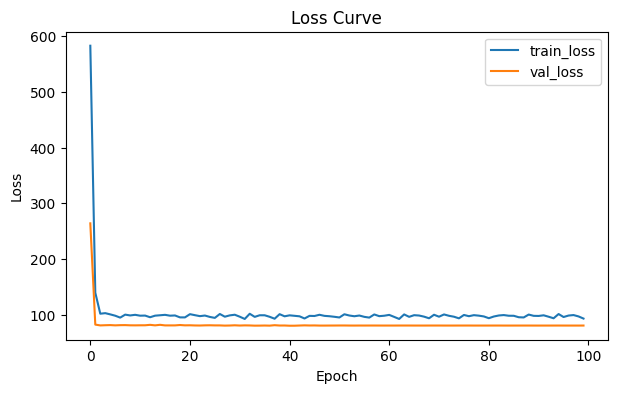

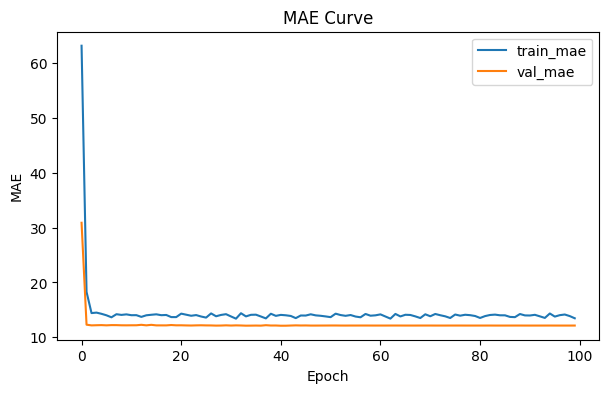

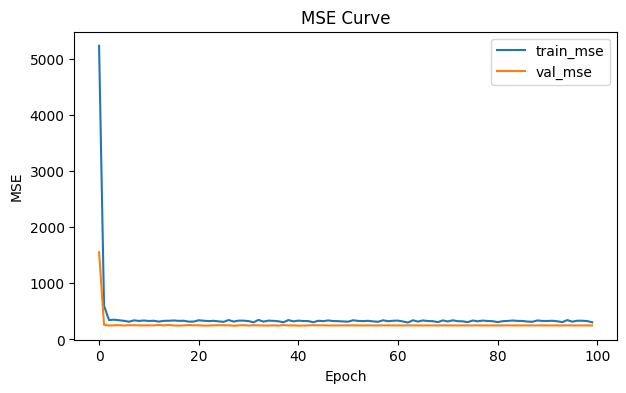

In [12]:
import matplotlib.pyplot as plt

hist = history.history

plt.figure(figsize=(7,4))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss Curve")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist["mae"], label="train_mae")
plt.plot(hist["val_mae"], label="val_mae")
plt.xlabel("Epoch"); plt.ylabel("MAE"); plt.legend(); plt.title("MAE Curve")
plt.show()

plt.figure(figsize=(7,4))
plt.plot(hist["mse"], label="train_mse")
plt.plot(hist["val_mse"], label="val_mse")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.title("MSE Curve")
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


 ECG_LSTM
Test loss: 11.284908294677734
Test MAE : 11.775114059448242
Test MSE : 227.29818725585938
MAE SBP  : 14.162463188171387
MAE DBP  : 9.387768745422363
MSE SBP  : 311.47259521484375
MSE DBP  : 143.1236572265625
Saved best: /content/drive/MyDrive/mimic_bp/single_modality_runs/ECG_LSTM/best_ECG_LSTM.keras


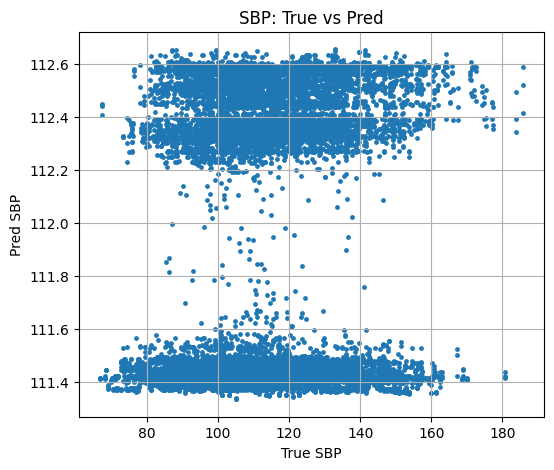

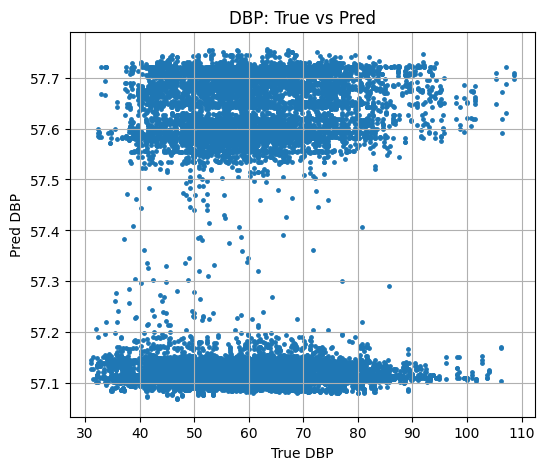

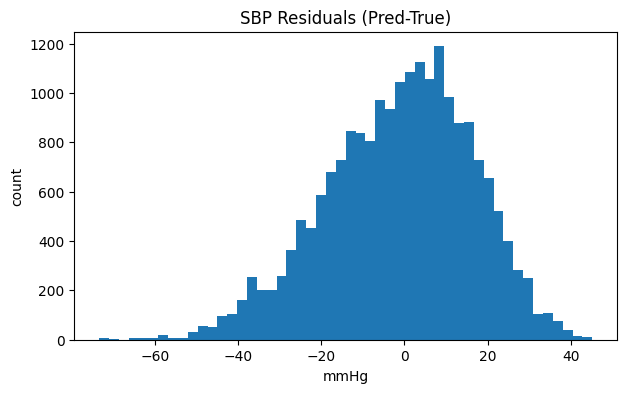

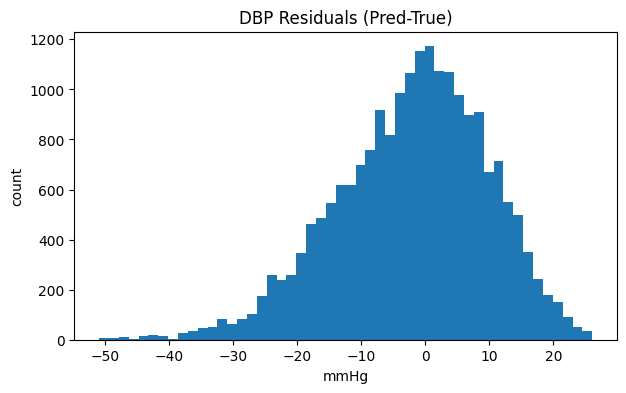

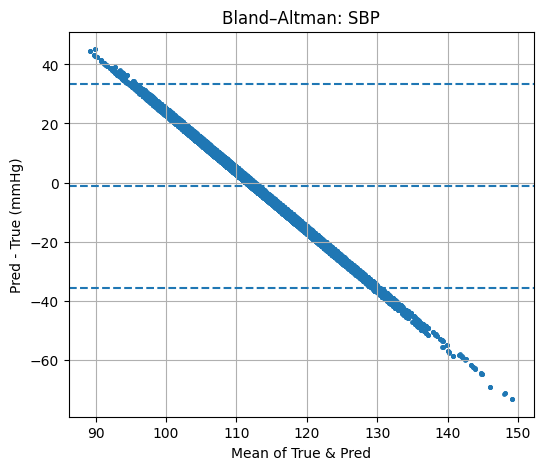

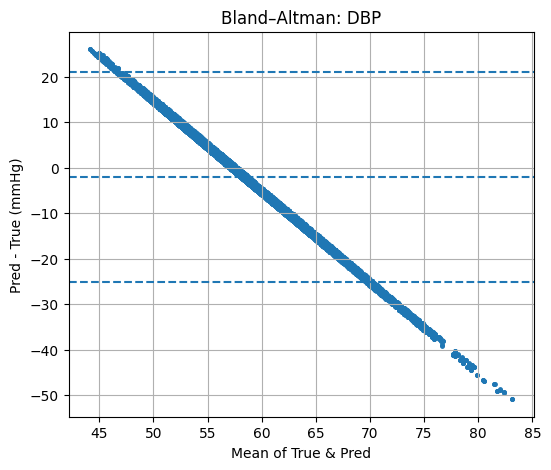

In [13]:
# ================== Cell 10 — Evaluate BEST on test + extra testing figures ==================
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

best_model = tf.keras.models.load_model(best_path)

test_loss, test_mae, test_mse = best_model.evaluate(test_data, verbose=0)

y_true, y_pred = [], []
for xb, yb in test_data:
    y_true.append(yb.numpy())
    y_pred.append(best_model.predict(xb, verbose=0))

y_true = np.concatenate(y_true, axis=0)
y_pred = np.concatenate(y_pred, axis=0)

mae_sbp = float(np.mean(np.abs(y_pred[:,0] - y_true[:,0])))
mae_dbp = float(np.mean(np.abs(y_pred[:,1] - y_true[:,1])))

mse_sbp = float(np.mean((y_pred[:,0] - y_true[:,0])**2))
mse_dbp = float(np.mean((y_pred[:,1] - y_true[:,1])**2))

print("", run_name)
print("Test loss:", float(test_loss))
print("Test MAE :", float(test_mae))
print("Test MSE :", float(test_mse))
print("MAE SBP  :", mae_sbp)
print("MAE DBP  :", mae_dbp)
print("MSE SBP  :", mse_sbp)
print("MSE DBP  :", mse_dbp)
print("Saved best:", best_path)

# -------- (A) Scatter: Pred vs True --------
plt.figure(figsize=(6,5))
plt.scatter(y_true[:,0], y_pred[:,0], s=6)
plt.xlabel("True SBP"); plt.ylabel("Pred SBP"); plt.title("SBP: True vs Pred")
plt.grid(True); plt.show()

plt.figure(figsize=(6,5))
plt.scatter(y_true[:,1], y_pred[:,1], s=6)
plt.xlabel("True DBP"); plt.ylabel("Pred DBP"); plt.title("DBP: True vs Pred")
plt.grid(True); plt.show()

# -------- (B) Error histograms --------
err_sbp = y_pred[:,0] - y_true[:,0]
err_dbp = y_pred[:,1] - y_true[:,1]

plt.figure(figsize=(7,4))
plt.hist(err_sbp, bins=50)
plt.title("SBP Residuals (Pred-True)"); plt.xlabel("mmHg"); plt.ylabel("count")
plt.show()

plt.figure(figsize=(7,4))
plt.hist(err_dbp, bins=50)
plt.title("DBP Residuals (Pred-True)"); plt.xlabel("mmHg"); plt.ylabel("count")
plt.show()

# -------- (C) Bland–Altman --------
def bland_altman(y_true_1d, y_pred_1d, title):
    mean_bp = (y_true_1d + y_pred_1d) / 2.0
    diff    = (y_pred_1d - y_true_1d)
    md = diff.mean()
    sd = diff.std()
    loa1 = md - 1.96*sd
    loa2 = md + 1.96*sd

    plt.figure(figsize=(6,5))
    plt.scatter(mean_bp, diff, s=6)
    plt.axhline(md, linestyle="--")
    plt.axhline(loa1, linestyle="--")
    plt.axhline(loa2, linestyle="--")
    plt.xlabel("Mean of True & Pred"); plt.ylabel("Pred - True (mmHg)")
    plt.title(title)
    plt.grid(True); plt.show()

bland_altman(y_true[:,0], y_pred[:,0], "Bland–Altman: SBP")
bland_altman(y_true[:,1], y_pred[:,1], "Bland–Altman: DBP")
